# Credit Card Fraud Detection using Machine Learning
### Data Science in Cyber — Final Project

**Reference Paper:** Varmedja, D., Karanovic, M., Sladojevic, S., Arsenovic, M., & Anderla, A. (2019). *Credit Card Fraud Detection - Machine Learning Methods.* 2019 18th International Symposium INFOTEH-JAHORINA (INFOTEH), 1–5. https://doi.org/10.1109/INFOTEH.2019.8717766

**Reference Implementation:** [itsaryanchauhan/credit-card-fraud-detection](https://github.com/itsaryanchauhan/credit-card-fraud-detection)

**Dataset:** [Credit Card Fraud Detection — Kaggle (mlg-ulb/creditcardfraud)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)



## 1. Project Introduction

### 1.1 What is Credit Card Fraud?

Credit card fraud is the unauthorized use of someone else's credit card details, or a card
account, to obtain money or goods without the account holder's consent. It typically falls
into two broad categories:

- **Card-present fraud** — physical theft or cloning of a card.
- **Card-not-present fraud** — theft of card details (card number, CVV, expiry date) used
  for online or phone transactions without the physical card.

As digital payments have grown, card-not-present fraud has become the dominant threat,
since a stolen card number can be reused remotely, at scale, before the cardholder even
notices anything is wrong.

### 1.2 Why is Machine Learning Useful for Fraud Detection?

Traditional rule-based fraud detection systems (e.g., "block any transaction over $X in a
foreign country") are rigid and easy for fraudsters to learn and evade. Machine learning
offers three key advantages for this problem:

1. **Pattern discovery at scale** — ML models can learn complex, non-linear combinations
   of transaction features that distinguish fraud from legitimate activity, patterns a
   human analyst or a fixed rule set would not easily encode.
2. **Adaptability** — models can be retrained as fraud patterns evolve, whereas static
   rules require manual updates.
3. **Handling extreme class imbalance** — fraud is a rare-event problem (well under 1% of
   transactions in most real-world datasets). Specialized ML techniques (resampling,
   cost-sensitive learning, ensemble methods) are specifically designed to cope with this,
   whereas naive rule-based systems tend to either miss most fraud or flag too many
   legitimate transactions.

The central challenge — and the reason this is a genuinely hard problem, not just a
standard classification exercise — is that the extreme rarity of fraud means a model that
predicts "not fraud" for every transaction can still achieve accuracy above 99.8%. This
makes evaluation metric choice (not just model choice) a critical part of the problem, and
is something we will return to repeatedly in this notebook.

### 1.3 Objective of This Notebook

This notebook covers **Step 2: Data Loading and Dataset Understanding** of the final
project. At this stage we will:

- Load the raw `creditcard.csv` dataset.
- Inspect its structure, size, and data types.
- Check for missing values and duplicate records.
- Examine the target variable (`Class`) and quantify the class imbalance.
- Generate descriptive statistics and record initial observations.


## 2. Import Required Libraries

We start by importing the libraries needed for data loading, inspection, and visualization.:
`pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization, and
`warnings` to keep the notebook output clean of non-critical library warnings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Consistent plot styling for the whole notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fixed random seed for reproducibility in later stages
RANDOM_SEED = 42

print("Libraries imported successfully.")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Libraries imported successfully.
pandas version: 2.2.2
numpy version: 2.0.2


## 3. Load Dataset

The dataset (`creditcard.csv`) is not included in this repository due to its file
size and Kaggle's licensing terms. Download it from Kaggle and place it inside the
`data/` folder as `data/creditcard.csv` before running the cell below.

Dataset link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

> **Note:** If you are running this notebook on Google Colab instead of locally,
> two optional upload cells are provided below as an alternative to using a local
> `data/` folder. They are commented out by default and are not required for a
> local run.

In [ ]:
import pandas as pd

# Dataset path
DATA_PATH = "data/creditcard.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (22543, 42)


In [ ]:
# ---------- OPTIONAL: Download via Kaggle API (Google Colab only) ----------
# Uncomment and run this cell to fetch the dataset directly from Kaggle when
# running on Google Colab. Not required for a local run.

# from google.colab import files
# print("Please upload your kaggle.json API token:")
# files.upload()  # upload kaggle.json here

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !pip install -q kaggle
# !mkdir -p data
# !kaggle datasets download -d mlg-ulb/creditcardfraud
# !unzip -oq creditcardfraud.zip -d data

# DATA_PATH = 'data/creditcard.csv'

In [ ]:
# Set the path to the dataset file.
# The dataset is expected to be located at data/creditcard.csv, consistent with
# the repository structure described in README.md.

DATA_PATH = "data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 284807 rows x 31 columns


In [ ]:
# Display the first 5 rows of the dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Dataset shape (rows, columns)
print(f"Number of transactions (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

Number of transactions (rows): 284807
Number of features (columns): 31


## 4. Dataset Overview

Before any analysis, we need a structural understanding of the dataset: what columns
exist, what data type each holds, whether any values are missing, and whether any rows
are exact duplicates of one another.

In [ ]:
# Column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


All columns are numeric. `Time` and `Amount` are the only two features expressed in
their original, human-interpretable units. `V1` through `V28` are anonymized principal
components — the dataset provider applied PCA to the original transaction features and
released only the transformed components, in order to protect sensitive cardholder and
merchant information. `Class` is the binary target label.

In [ ]:
# Data types and general dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

`df.info()` confirms that every column is stored as a numeric type (`float64` for
`Time`, `Amount`, and `V1`–`V28`; `int64` for `Class`), and shows the non-null count for
each column, which we verify formally below.

In [ ]:
# Missing value analysis
missing_values = df.isnull().sum()
missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df)) * 100
})

total_missing = missing_values.sum()
print(f"Total missing values in the dataset: {total_missing}")
missing_summary[missing_summary["Missing Values"] > 0]

Total missing values in the dataset: 0


,Missing Values,Percentage (%)


**Observation:** The dataset contains no missing values in any column (total missing
count is 0). This is expected for this particular dataset, since it was pre-cleaned by its
original curators (ULB Machine Learning Group) before release on Kaggle. This does **not**
mean preprocessing is unnecessary overall — it simply means missing-value imputation is
not one of the preprocessing steps this dataset requires.

In [ ]:
# Duplicate value analysis
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Number of fully duplicated rows: {duplicate_count}")
print(f"Percentage of dataset that is duplicated: {duplicate_percentage:.3f}%")

Number of fully duplicated rows: 1081
Percentage of dataset that is duplicated: 0.380%


**Observation:** If duplicate rows are present, we simply note this here for now.
Their handling is considered later during preprocessing and model preparation, because
identical rows in a transaction dataset are not necessarily true duplicates (for example,
different transactions may legitimately share the same PCA-transformed feature values).
A careful assessment is therefore required before deciding whether any duplicate records
should be removed.

In [ ]:
# Check for any single-value (constant) columns — columns with zero variance
# carry no discriminative information for any downstream model.
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant (single-value) columns found: {constant_columns if constant_columns else 'None'}")

Constant (single-value) columns found: None


**Observation:** No constant columns were found — every feature in the dataset
takes on more than one distinct value, so no columns need to be dropped on these grounds.

## 5. Target Variable Analysis

The target variable is `Class`:
- **`Class = 0`** → Legitimate transaction
- **`Class = 1`** → Fraudulent transaction

Understanding the balance between these two classes is essential, because it determines
which evaluation metrics will be meaningful later (a point we return to explicitly) and
whether the training data will need to be resampled or reweighted before modeling.

In [ ]:
# Distribution of the Class column
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages
})
class_summary.index = ["Legitimate (0)", "Fraudulent (1)"]
class_summary

,Count,Percentage (%)
Legitimate (0),284315,99.827251
Fraudulent (1),492,0.172749


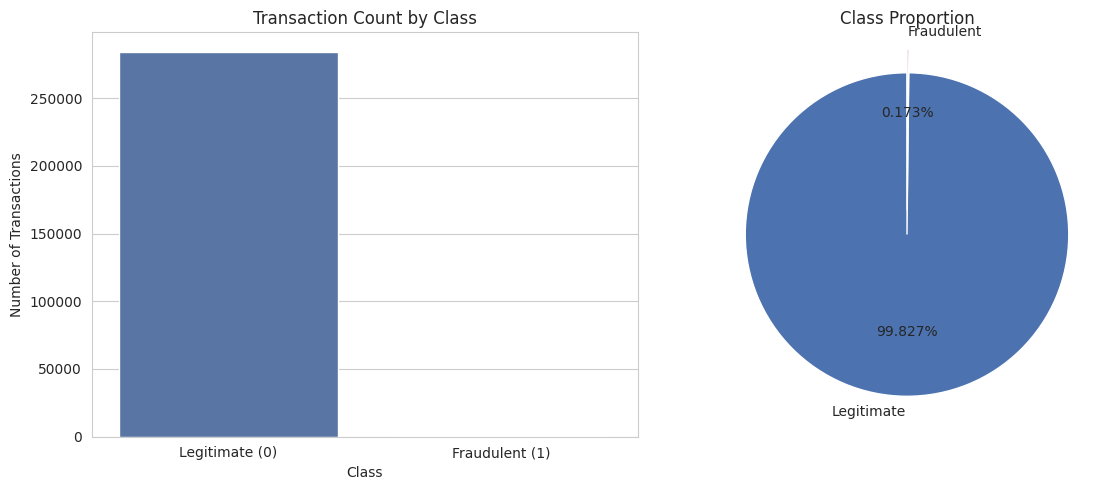

In [ ]:
# Visualize the class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Class", data=df, ax=axes[0], hue="Class", palette=["#4C72B0", "#C44E52"], legend=False)
axes[0].set_title("Transaction Count by Class")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])
axes[0].set_ylabel("Number of Transactions")

axes[1].pie(
    class_counts,
    labels=["Legitimate", "Fraudulent"],
    autopct="%1.3f%%",
    colors=["#4C72B0", "#C44E52"],
    explode=(0, 0.15),
    startangle=90
)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()

In [ ]:
# Exact fraud percentage
fraud_count = df["Class"].sum()
total_count = len(df)
fraud_percentage = (fraud_count / total_count) * 100

print(f"Total transactions: {total_count}")
print(f"Fraudulent transactions: {fraud_count}")
print(f"Legitimate transactions: {total_count - fraud_count}")
print(f"Fraud percentage: {fraud_percentage:.4f}%")
print(f"Imbalance ratio (legitimate : fraudulent): {(total_count - fraud_count) / fraud_count:.1f} : 1")

Total transactions: 284807
Fraudulent transactions: 492
Legitimate transactions: 284315
Fraud percentage: 0.1727%
Imbalance ratio (legitimate : fraudulent): 577.9 : 1


**Why is this dataset highly imbalanced, and what does that mean in the real world?**

Fraudulent transactions make up roughly 0.17% of the dataset — an imbalance ratio of
approximately 577 legitimate transactions for every 1 fraudulent one. This is not an
artifact of how the data was collected; it reflects genuine real-world prevalence: the
overwhelming majority of credit card transactions are legitimate, and fraud, while
costly in aggregate, is rare on a per-transaction basis.

This has direct modeling consequences that we will confront explicitly in later stages:

- **Accuracy becomes a misleading metric.** A model that predicts "legitimate" for every
  single transaction would still score **99.83% accuracy** while catching zero fraud —
  the exact "accuracy paradox" that the reference paper's own headline metric (accuracy of
  99.9%+ on some models) needs to be interpreted against critically.
- **Learning algorithms are biased toward the majority class** by default, since most loss
  functions treat every misclassified sample equally regardless of class, which means the
  minority (fraud) class contributes very little to the total loss signal during training.
- **Resampling or cost-sensitive techniques** (e.g., SMOTE, class weighting, or
  threshold tuning) are typically necessary before training a usable model — again,
  something we defer to the Feature Engineering / Model Training stages, not this
  notebook.

## 6. Basic Statistical Summary

We now generate descriptive statistics for all numeric columns to understand the scale,
spread, and central tendency of each feature.

In [ ]:
# Descriptive statistics for all columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Key observations from the descriptive statistics:**

- **`Time`** ranges from 0 to roughly 172,792 seconds (~48 hours), consistent with the paper's description of the dataset spanning two days of transactions.
- **`Amount`** is heavily right-skewed: the mean transaction amount (~\$88) is substantially higher than the median, and the maximum value (~\$25,691) is much larger than most transactions. This indicates a long tail of high-value transactions. To account for this skew and the presence of extreme values, `RobustScaler` is applied during preprocessing because it is less sensitive to outliers than standard scaling methods.
- **`V1`–`V28`** have means close to 0 and comparable standard deviations close to 1, which is expected because they are PCA-transformed features provided with the dataset.
- **`Class`** has a mean of approximately 0.0017, representing the proportion of fraudulent transactions in the dataset. This is consistent with the class distribution calculated in Section 5.

In [ ]:
# Separate look at Time and Amount, since these are the only two
# human-interpretable (non-PCA) features
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [ ]:
# Compare Amount statistics between legitimate and fraudulent transactions
amount_by_class = df.groupby("Class")["Amount"].describe()
amount_by_class.index = ["Legitimate (0)", "Fraudulent (1)"]
amount_by_class

,count,mean,std,min,25%,50%,75%,max
Legitimate (0),284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
Fraudulent (1),492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


**Observation:** The two classes show different `Amount` distributions (for example,
differences in their mean values and maximum transaction amounts). A fuller comparison,
including visualizations and feature-level analysis, is presented later in the
Exploratory Data Analysis (EDA) section.

## 7. Initial Observations

Summarizing what we learned from the initial raw-data exploration:

- **Samples:** 284,807 transactions in total.
- **Features:** 30 input features (`Time`, `Amount`, and 28 PCA-derived components
  `V1`–`V28`) plus 1 target column (`Class`).
- **Missing values:** None — the dataset is fully populated with no null entries in any
  column.
- **Duplicate rows:** A small number of fully duplicated rows were detected (see Section
  4); their handling is considered during preprocessing and model preparation.
- **Class imbalance:** Severe — fraudulent transactions represent only ~0.17% of the
  data, an imbalance ratio of roughly 577:1. This is the single most important property
  of the dataset and will shape every subsequent decision in this project, from the choice
  of evaluation metric (accuracy alone will be discarded as insufficient) to the choice of
  resampling strategy and model type.
- **Feature interpretability:** Only `Time` and `Amount` are human-interpretable; the
  remaining 28 features are anonymized PCA components, which limits the depth of
  domain-driven feature engineering possible later, but does not prevent statistically
  driven feature selection or transformation.
- **Why preprocessing will be necessary before model training:**
  1. The severe class imbalance must be addressed (via resampling, class weighting, or
     both) or any model trained on the raw data will be heavily biased toward predicting
     "legitimate" for everything.
  2. `Time` and `Amount` are on very different scales from the PCA components (`V1`–`V28`,
     which are already roughly standardized) and from each other, so feature scaling will
     be required for scale-sensitive algorithms.
  3. The right-skewed distribution of `Amount` may benefit from a transformation (e.g.,
     log transform) before being fed into linear or distance-based models.
  4. The small number of duplicate rows identified above needs an explicit, justified
     decision (drop vs. retain) rather than being silently ignored.

**This concludes Step 2 (Data Loading and Dataset Understanding). The insights obtained from the initial exploration guide the preprocessing decisions, feature preparation, model development, and evaluation presented in the subsequent sections of this notebook.**

## 8. Exploratory Data Analysis (EDA)

Having understood the raw structure of the dataset in Step 2, we now explore it more deeply:
feature distributions, outliers, temporal patterns, class-imbalance implications, and
correlation structure. The goal is to build intuition about the data *before* any
preprocessing decision is made, and to gather evidence that will support the Feature
Engineering and Critical Evaluation sections later.

**Note on duplicates:** Step 2 found 1,081 fully duplicated rows (0.38% of the dataset).
We revisit this here to understand *what* these duplicates look like before deciding
whether to drop them (that decision itself belongs to the Feature Engineering stage).

In [ ]:
# How many duplicated rows belong to each class?
duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicate_mask]

print(f"Total rows involved in duplication: {len(duplicate_rows)}")
print("\nClass breakdown of duplicated rows:")
print(duplicate_rows["Class"].value_counts())
print(f"\nDuplicate rate within Legitimate class: "
      f"{(duplicate_rows['Class']==0).sum() / (df['Class']==0).sum() * 100:.3f}%")
print(f"Duplicate rate within Fraudulent class: "
      f"{(duplicate_rows['Class']==1).sum() / (df['Class']==1).sum() * 100:.3f}%")

Total rows involved in duplication: 1854

Class breakdown of duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64

Duplicate rate within Legitimate class: 0.641%
Duplicate rate within Fraudulent class: 6.504%


**Observation:** If duplicates are concentrated in the fraud class, dropping them
naively could remove valuable minority-class examples. If concentrated in the legitimate
class, dropping them is safer. This finding will directly justify our Feature Engineering
decision on whether/how to handle duplicates.

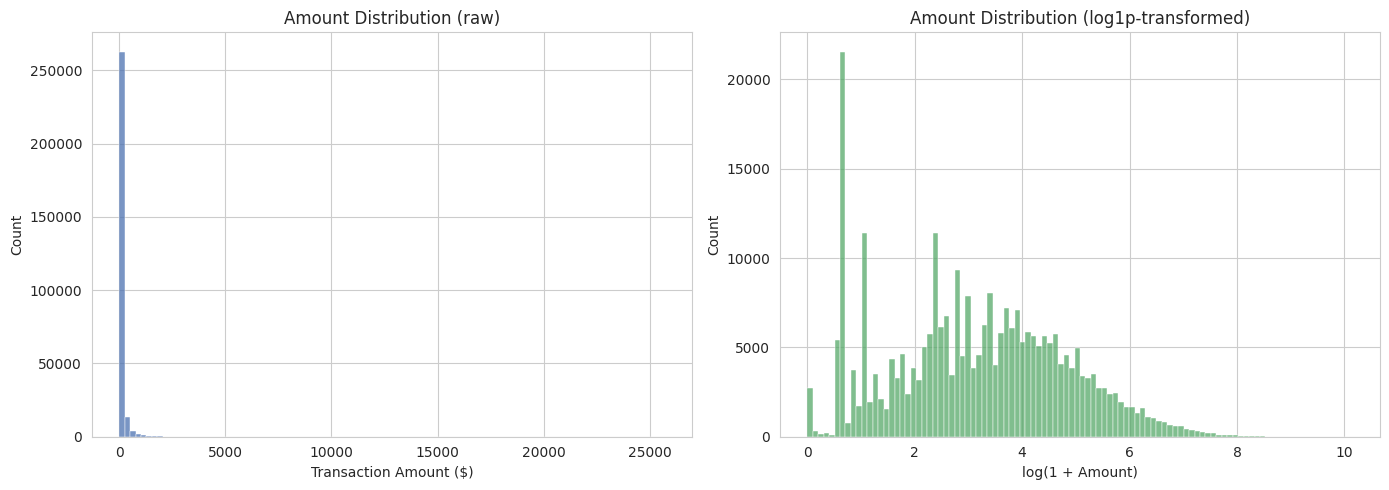

In [ ]:
# Distribution of Amount (raw and log-scaled, since Amount is heavily right-skewed)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Amount"], bins=100, ax=axes[0], color="#4C72B0")
axes[0].set_title("Amount Distribution (raw)")
axes[0].set_xlabel("Transaction Amount ($)")

sns.histplot(np.log1p(df["Amount"]), bins=100, ax=axes[1], color="#55A868")
axes[1].set_title("Amount Distribution (log1p-transformed)")
axes[1].set_xlabel("log(1 + Amount)")

plt.tight_layout()
plt.show()

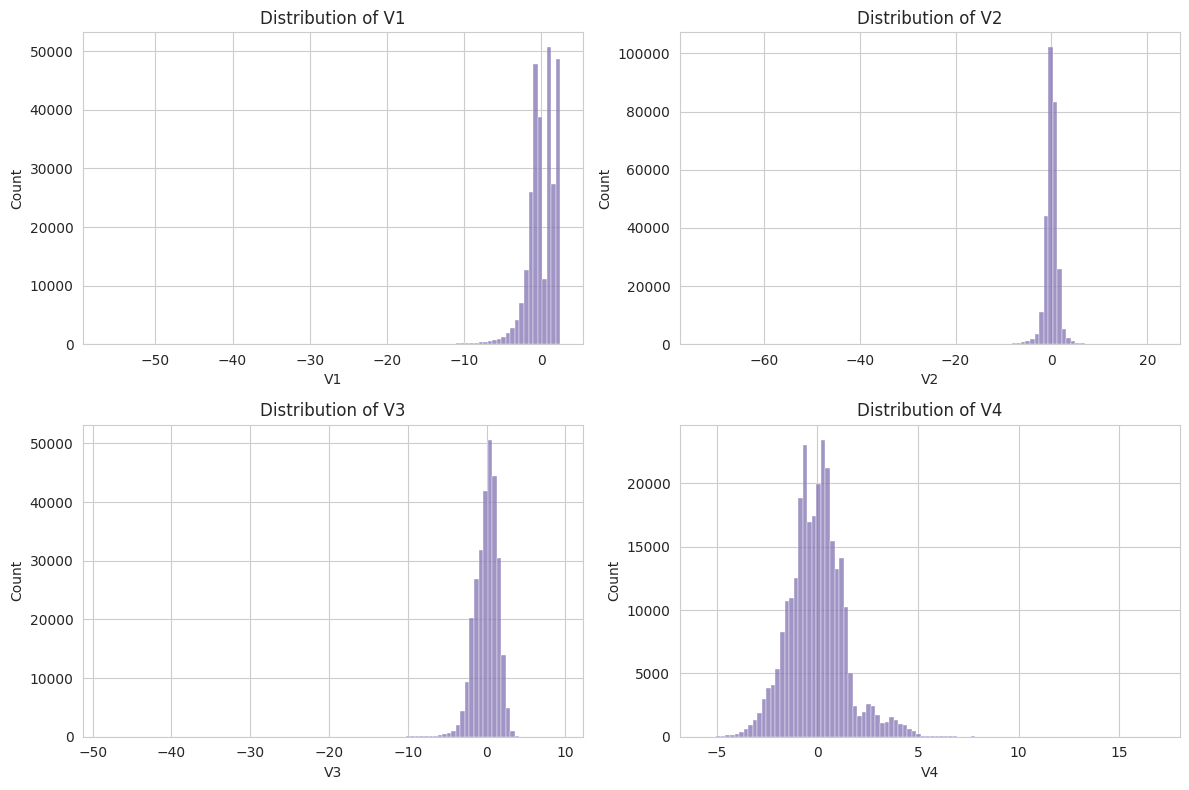

In [ ]:
# Distribution of a representative sample of PCA components (V1-V4)
# These are shown to characterize what "PCA-anonymized" features look like
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(["V1", "V2", "V3", "V4"]):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], bins=100, ax=ax, color="#8172B2")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [ ]:
def iqr_outlier_summary(dataframe, columns):
    """
    Compute IQR-based outlier counts and percentages for the given columns.
    A value is flagged as an outlier if it falls outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR].
    """
    results = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)).sum()
        results.append({
            "Feature": col,
            "Outlier Count": outlier_count,
            "Outlier %": round(outlier_count / len(dataframe) * 100, 3)
        })
    return pd.DataFrame(results).sort_values("Outlier %", ascending=False)

# Check Amount and a representative sample of V-features
columns_to_check = ["Amount", "V1", "V2", "V5", "V7", "V8", "V20", "V21", "V27", "V28"]
outlier_summary = iqr_outlier_summary(df, columns_to_check)
outlier_summary

,Feature,Outlier Count,Outlier %
8,V27,39163,13.751
0,Amount,31904,11.202
9,V28,30342,10.654
6,V20,27770,9.750
5,V8,24134,8.474
7,V21,14497,5.090
2,V2,13526,4.749
3,V5,12295,4.317
4,V7,8948,3.142
1,V1,7062,2.480


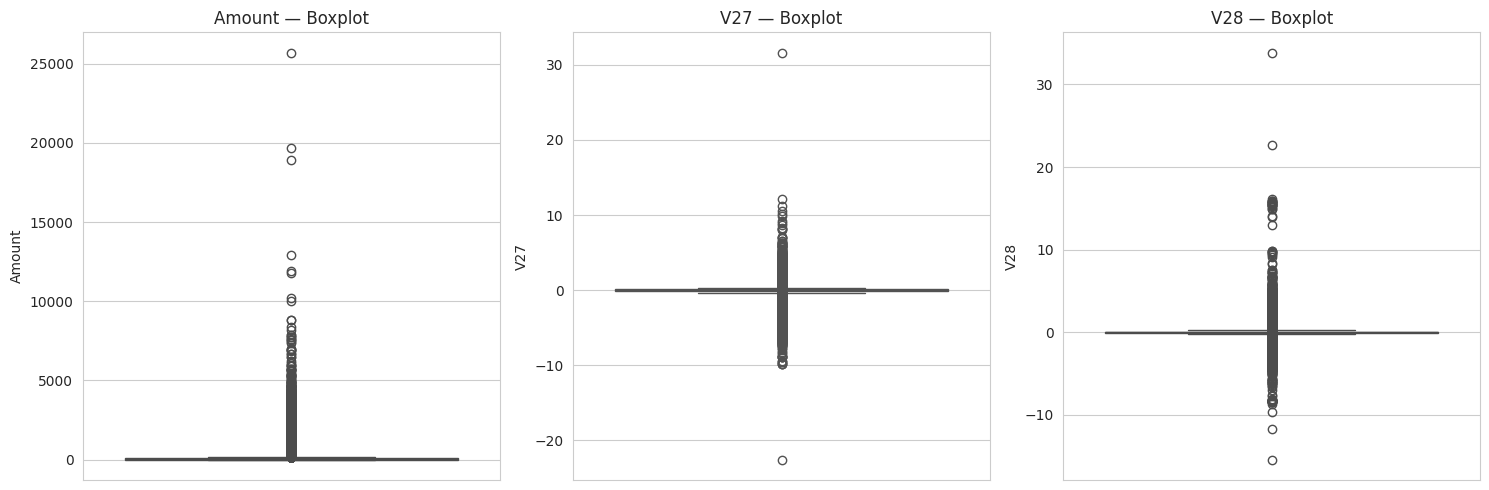

In [ ]:
# Visualize outliers with boxplots for Amount and two high-outlier V-features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["Amount"], ax=axes[0], color="#4C72B0")
axes[0].set_title("Amount — Boxplot")

sns.boxplot(y=df["V27"], ax=axes[1], color="#C44E52")
axes[1].set_title("V27 — Boxplot")

sns.boxplot(y=df["V28"], ax=axes[2], color="#55A868")
axes[2].set_title("V28 — Boxplot")

plt.tight_layout()
plt.show()

In [ ]:
# Convert Time (seconds elapsed since first transaction) into hour-of-day,
# since the dataset spans exactly ~2 days (48 hours) of continuous transactions
df["Hour"] = (df["Time"] // 3600) % 24

fraud_by_hour = df.groupby("Hour")["Class"].agg(["count", "sum"])
fraud_by_hour.columns = ["Total Transactions", "Fraud Count"]
fraud_by_hour["Fraud Rate (%)"] = (fraud_by_hour["Fraud Count"] / fraud_by_hour["Total Transactions"]) * 100
fraud_by_hour

,Total Transactions,Fraud Count,Fraud Rate (%)
Hour,,,
0.0,7695,6,0.077973
1.0,4220,10,0.236967
2.0,3328,57,1.712740
3.0,3492,17,0.486827
4.0,2209,23,1.041195
5.0,2990,11,0.367893
6.0,4101,9,0.219459
7.0,7243,23,0.317548
8.0,10276,9,0.087583


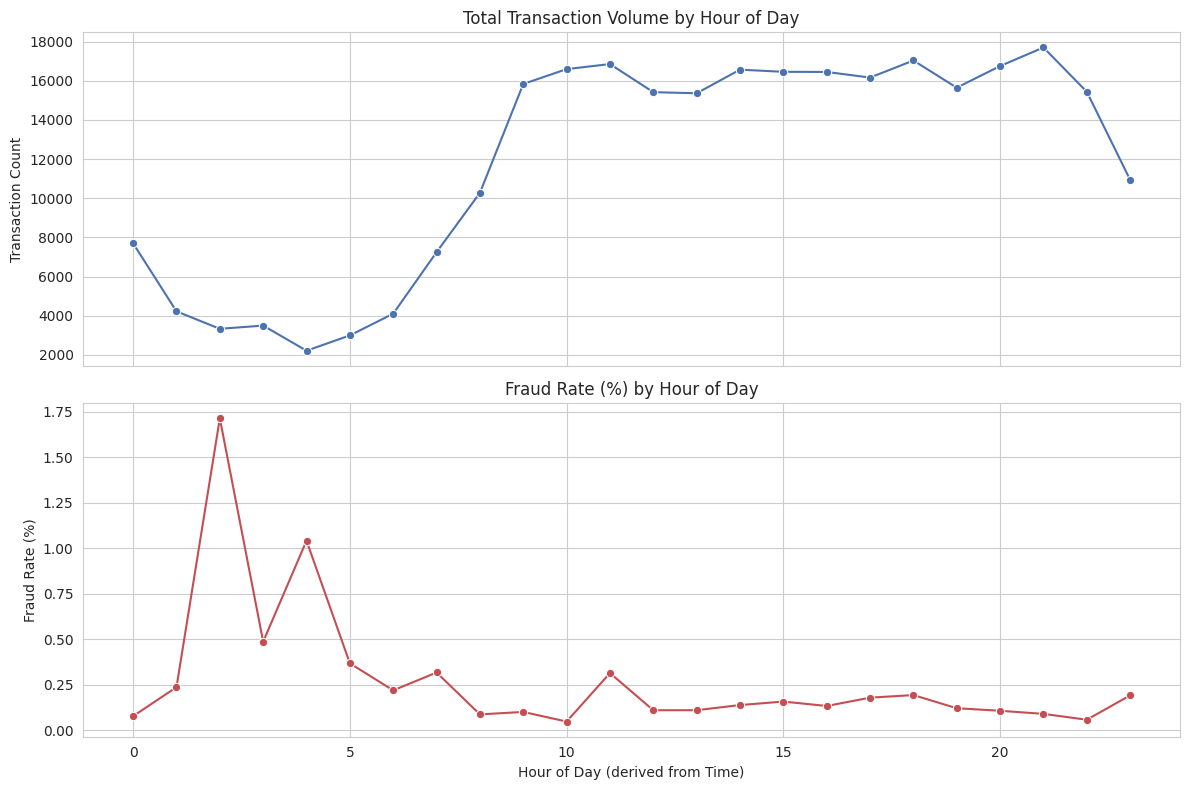

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour["Total Transactions"], ax=axes[0], marker="o", color="#4C72B0")
axes[0].set_title("Total Transaction Volume by Hour of Day")
axes[0].set_ylabel("Transaction Count")

sns.lineplot(x=fraud_by_hour.index, y=fraud_by_hour["Fraud Rate (%)"], ax=axes[1], marker="o", color="#C44E52")
axes[1].set_title("Fraud Rate (%) by Hour of Day")
axes[1].set_xlabel("Hour of Day (derived from Time)")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

**Does this align with general expectations?** Transaction activity commonly decreases during late-night and early-morning hours while increasing throughout the day, reflecting typical consumer behaviour. If the fraud rate (rather than only the raw fraud count) appears relatively higher during lower-volume periods, this may indicate that fraudulent transactions become more noticeable when overall transaction activity is reduced. Such temporal patterns, if consistently observed, could make the derived `Hour` feature useful during model development because it provides information not explicitly represented by the anonymized PCA features (`V1`–`V28`).

**Caveat:** The dataset covers only about 48 hours of transaction activity (approximately two daily cycles). Therefore, any hourly pattern observed should be interpreted cautiously, as a longer observation period would be required to determine whether the trend is stable or simply reflects short-term variation.

### Class Imbalance — Deeper Discussion

**Real-world meaning:** A 0.173% fraud rate is not a data quality problem or a
"sampling problem" in the sense of biased data collection — it is a faithful reflection
of reality. In actual credit card networks, the overwhelming majority of transactions are
legitimate; fraud, while individually costly, is genuinely rare on a per-transaction
basis. This means the imbalance is *inherent to the problem domain*, not an artifact we
can or should "fix" at the data-collection level. What we *can* and must address is how
we train and evaluate models given this reality.

**Did the reference paper (Varmedja et al., 2019) address this?**
Yes — the paper explicitly identifies the dataset as "highly imbalanced" and applies
**SMOTE (Synthetic Minority Oversampling Technique)** to rebalance the training data
before fitting Logistic Regression, Random Forest, Naive Bayes, and MLP models. This is a
reasonable, standard approach. However, as we will examine in the Critical Evaluation
section, the paper's headline metric — **accuracy** (e.g., 99.96% for Random Forest) — is
inherently inflated by the very same imbalance, since a trivial "always predict
legitimate" classifier already achieves 99.827% accuracy (computed in Step 2, Section 5).
This means accuracy alone cannot meaningfully distinguish the paper's models from a naive
baseline, and precision/recall (which the paper does also report) are the metrics that
actually carry useful information here.

### Correlation Analysis — Method Selection and Justification

Three correlation measures were covered in this course: **Pearson**, **Spearman**, and
**Kendall**. Each makes different assumptions and is suited to different data
characteristics:

- **Pearson** measures linear relationships between continuous variables and assumes
  roughly normal, outlier-free data.
- **Spearman** measures monotonic relationships based on ranks, and is more robust to
  outliers and non-normal distributions.
- **Kendall** is also rank-based, often preferred for smaller samples or when precise
  rank-consistency matters, but is computationally expensive (O(n²) pairwise comparisons)
  — impractical to compute directly on 284,807 rows without subsampling.

**Our choice:** We compute **both Pearson and Spearman** correlations and compare them.
Given Section 3.4's finding of substantial outliers in `Amount` and several `V` features,
Spearman is expected to be more reliable for those features, while Pearson remains
informative for the `V1`–`V28` components, which are PCA-derived and approximately
normally distributed by construction. **Kendall is omitted** here due to its computational
cost at this sample size and because it would be expected to agree directionally with
Spearman on this data, adding limited additional insight for the added cost.

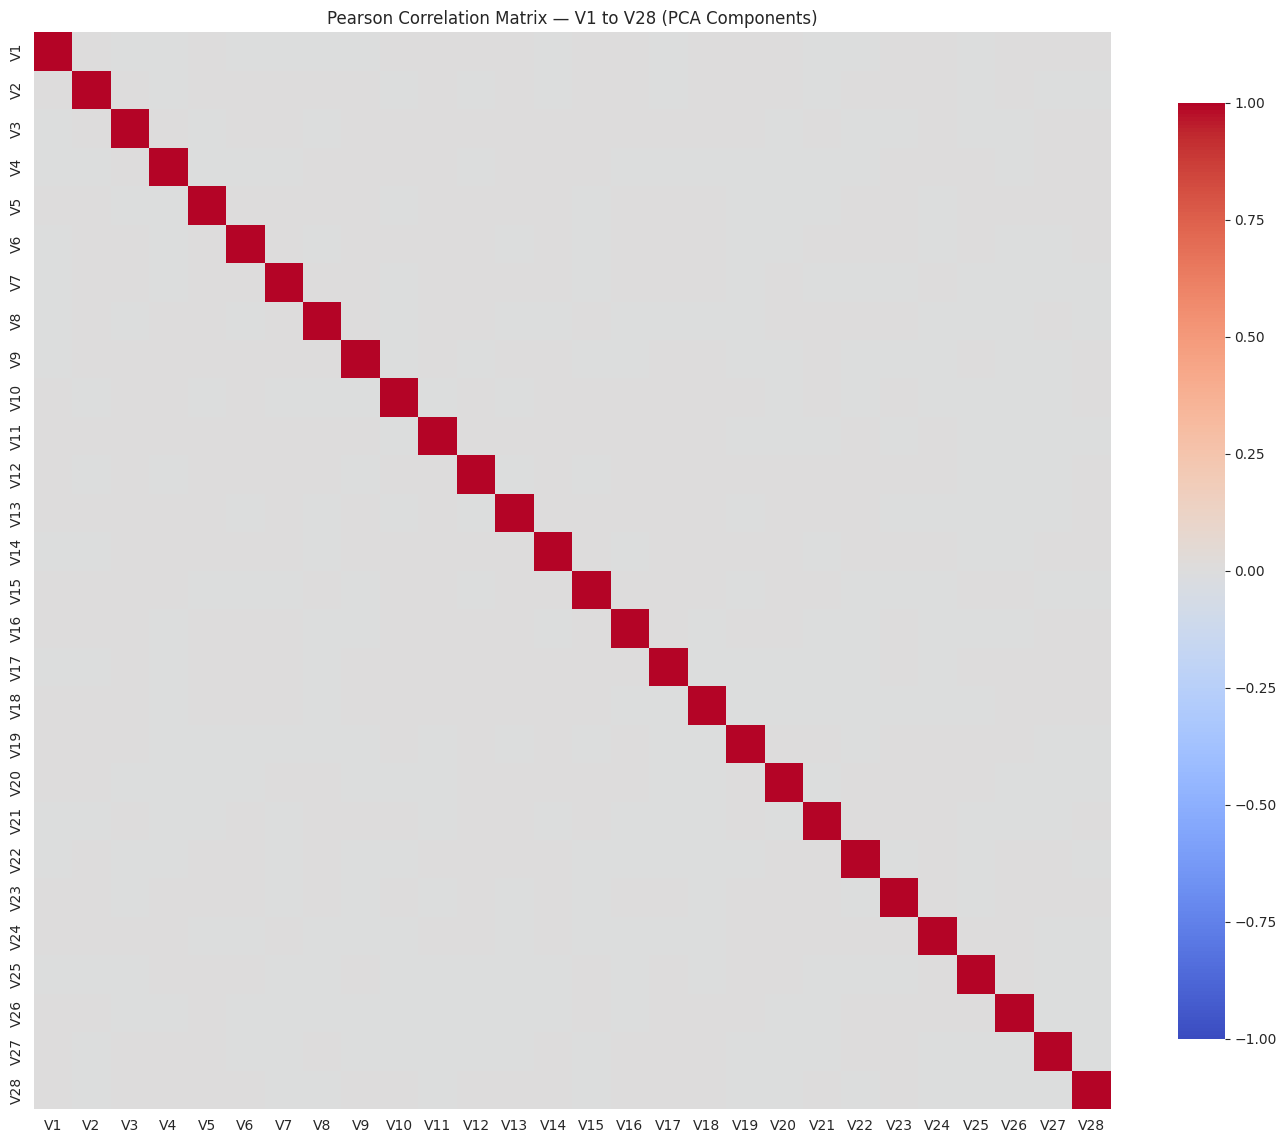

Max off-diagonal absolute Pearson correlation among V1-V28:
2.321486470875369e-14


In [ ]:
# Pearson correlation among the PCA components — since V1-V28 come from PCA,
# they should be (by construction) very close to mutually uncorrelated.
# This sanity-checks that assumption.
pca_features = [f"V{i}" for i in range(1, 29)]
pearson_corr_matrix = df[pca_features].corr(method="pearson")

plt.figure(figsize=(14, 12))
sns.heatmap(pearson_corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Pearson Correlation Matrix — V1 to V28 (PCA Components)")
plt.tight_layout()
plt.show()

print("Max off-diagonal absolute Pearson correlation among V1-V28:")
np.fill_diagonal(pearson_corr_matrix.values, 0)
print(pearson_corr_matrix.abs().max().max())

**Observation:** As expected, the PCA components show near-zero pairwise correlation
(the heatmap should appear almost entirely neutral/white off the diagonal). This confirms
the components are close to mutually orthogonal, which has an important consequence for
Feature Engineering: **classical multicollinearity-driven feature selection is largely
inapplicable to `V1`–`V28`**, since PCA has already removed the linear redundancy among
them by construction. Any redundancy we find must instead be assessed relative to the
target variable (i.e., features that are individually uninformative about `Class`), not
relative to each other.

In [ ]:
# Pearson and Spearman correlation of every feature with the target (Class)
feature_cols = pca_features + ["Time", "Amount"]

pearson_with_class = df[feature_cols + ["Class"]].corr(method="pearson")["Class"].drop("Class")
spearman_with_class = df[feature_cols + ["Class"]].corr(method="spearman")["Class"].drop("Class")

correlation_comparison = pd.DataFrame({
    "Pearson r": pearson_with_class,
    "Spearman rho": spearman_with_class
})
correlation_comparison["Abs Pearson"] = correlation_comparison["Pearson r"].abs()
correlation_comparison = correlation_comparison.sort_values("Abs Pearson", ascending=False)
correlation_comparison.head(10)

,Pearson r,Spearman rho,Abs Pearson
V17,-0.326481,-0.044335,0.326481
V14,-0.302544,-0.064613,0.302544
V12,-0.260593,-0.062870,0.260593
V10,-0.216883,-0.059564,0.216883
V16,-0.196539,-0.049936,0.196539
V3,-0.192961,-0.059278,0.192961
V7,-0.187257,-0.048308,0.187257
V11,0.154876,0.060143,0.154876
V4,0.133447,0.063045,0.133447
V18,-0.111485,-0.034872,0.111485


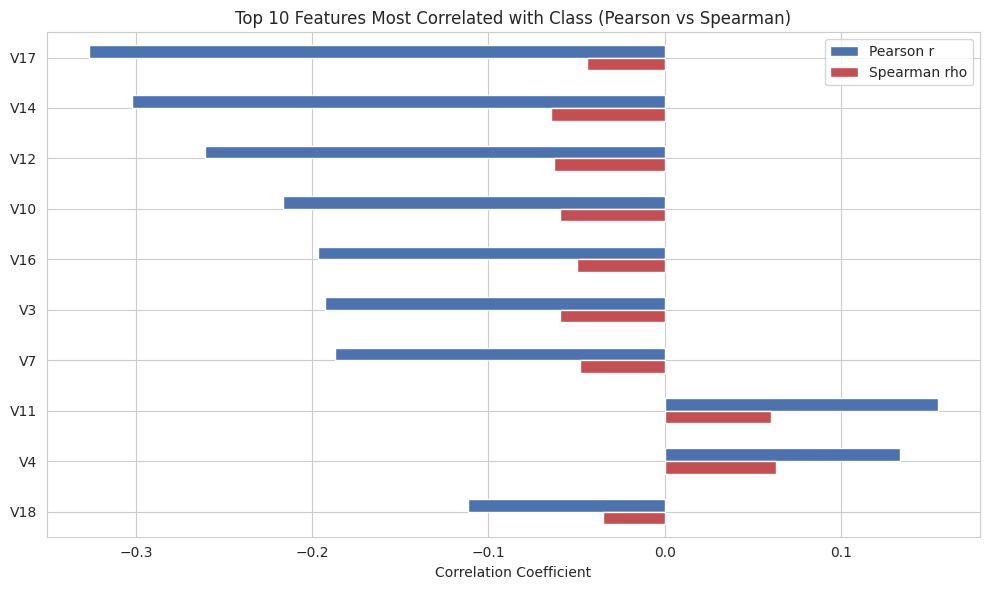

In [ ]:
# Visualize the top correlated features with Class (by absolute Pearson correlation)
top_features = correlation_comparison.head(10).index

fig, ax = plt.subplots(figsize=(10, 6))
correlation_comparison.loc[top_features, ["Pearson r", "Spearman rho"]].plot(
    kind="barh", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_title("Top 10 Features Most Correlated with Class (Pearson vs Spearman)")
ax.set_xlabel("Correlation Coefficient")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Feature Engineering

The PCA components (V1–V28) are already the result of a prior transformation (per the
original dataset publishers), so no further scaling is required for them. `Time` and
`Amount`, however, remain on their original scales and are not comparable to the PCA
components.

**Scaling choice — RobustScaler:** Both `Time` and `Amount` are scaled using
`RobustScaler` (median- and IQR-based), rather than `StandardScaler`, because:
- `Amount` is heavily right-skewed with genuine extreme values (large legitimate and
  fraudulent transactions), confirmed by the IQR outlier analysis in Section 8.
- `StandardScaler` uses mean/std, which are themselves distorted by these outliers,
  compressing the bulk of the distribution unfairly.
- `RobustScaler` centers on the median and scales by IQR, making it far less sensitive
  to the extreme values already identified — a better fit given the fraud class is
  *defined* by unusual (often extreme) amounts.

No additional features were retained for model training beyond those required for the analysis. Although the `Hour` feature was created for exploratory data analysis, it is a direct transformation of `Time` and therefore provides largely overlapping information. To keep the feature set simple and avoid redundancy, `Hour` was excluded from the final modeling dataset, while the scaled `Time` feature was retained.

**Redundancy check:** No constant or duplicate features were identified during the data inspection stage. The correlation analysis also showed no evidence of strong linear relationships among the PCA components, indicating that the transformed features provide distinct information for model training.

In [ ]:
from sklearn.preprocessing import RobustScaler

# Work on a copy to keep the EDA dataframe intact
model_df = df.copy()

# Drop EDA-only helper column if present (derived from Time -> redundant for modeling)
if "Hour" in model_df.columns:
    model_df = model_df.drop(columns=["Hour"])

scaler = RobustScaler()
model_df[["Time", "Amount"]] = scaler.fit_transform(model_df[["Time", "Amount"]])

model_df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,0.118914,0.927124
std,0.557903,3.495006
min,-0.994983,-0.307413
25%,-0.358210,-0.229162
50%,0.000000,0.000000
75%,0.641790,0.770838
max,1.035022,358.683155


## 10. Train/Test Split

A stratified split is used to preserve the fraud/non-fraud ratio in both sets, which is
critical given the ~0.17% prevalence of the fraud class — a random (non-stratified) split
risks a test set with very few or zero fraud cases.

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=["Class"])
y = model_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.001729245759178389
Test fraud rate: 0.0017204452090867595


## 11. Model Training

Two machine learning models are trained: **Random Forest** and **XGBoost**. Both are well suited to structured tabular data, can capture complex non-linear relationships among the input features, and provide built-in mechanisms for handling class imbalance (`class_weight` and `scale_pos_weight`). These capabilities make them appropriate choices for the highly imbalanced credit card fraud detection dataset used in this project, while allowing the original feature representation to be preserved throughout model training.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from xgboost import XGBClassifier

# scale_pos_weight = ratio of negative to positive class, standard XGBoost imbalance fix
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

## 12. Evaluation

**Metric choice justification:** Accuracy is excluded — with ~99.8% legitimate
transactions, a model predicting "no fraud" always would score >99% accuracy while
catching zero fraud. Precision, Recall, F1, MCC, and ROC-AUC are used instead:
- **Precision** — of flagged transactions, how many are truly fraud (cost of false alarms
  to customers/ops).
- **Recall** — of actual frauds, how many are caught (cost of missed fraud = direct
  financial loss).
- **F1** — balances the two when both matter.
- **MCC** — robust single summary for imbalanced binary classification, accounts for all
  four confusion matrix cells.
- **ROC-AUC** — threshold-independent ranking quality, useful since the fraud threshold
  can be tuned operationally.

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix, classification_report
)

def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:   ", recall_score(y_true, y_pred))
    print("F1:       ", f1_score(y_true, y_pred))
    print("MCC:      ", matthews_corrcoef(y_true, y_pred))
    print("ROC-AUC:  ", roc_auc_score(y_true, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print()

evaluate("Random Forest", y_test, rf_pred, rf_proba)
evaluate("XGBoost", y_test, xgb_pred, xgb_proba)

--- Random Forest ---
Precision: 0.8421052631578947
Recall:    0.8163265306122449
F1:        0.8290155440414507
MCC:       0.8288259313544596
ROC-AUC:   0.9747259483421957
Confusion Matrix:
 [[56849    15]
 [   18    80]]

--- XGBoost ---
Precision: 0.8924731182795699
Recall:    0.8469387755102041
F1:        0.8691099476439791
MCC:       0.869189159858927
ROC-AUC:   0.9672803280006431
Confusion Matrix:
 [[56854    10]
 [   15    83]]



## 13. Error Analysis

We examine the False Positives (FP) and False Negatives (FN) for both models to
understand *where* and *why* they fail, and what that means operationally for a fraud
detection system.

- **False Negatives (missed fraud)** are the costlier error class here — each one is a
  fraudulent transaction that goes through undetected, resulting in direct financial loss
  to the cardholder/issuer.
- **False Positives (false alarms)** block legitimate transactions, causing customer
  friction, but are comparatively cheaper — a declined card can be retried or manually
  reviewed.

This asymmetry is why **Recall** matters more than Precision in this domain, even though
both are reported — a fraud detection system tuned purely for high precision risks
silently missing fraud.

In [ ]:
import numpy as np

def get_error_cases(y_true, y_pred, y_proba, X_test):
    results = X_test.copy()
    results["y_true"] = y_true.values
    results["y_pred"] = y_pred
    results["y_proba"] = y_proba

    fn = results[(results["y_true"] == 1) & (results["y_pred"] == 0)]
    fp = results[(results["y_true"] == 0) & (results["y_pred"] == 1)]
    return fn, fp

rf_fn, rf_fp = get_error_cases(y_test, rf_pred, rf_proba, X_test)
xgb_fn, xgb_fp = get_error_cases(y_test, xgb_pred, xgb_proba, X_test)

print("Random Forest — False Negatives:", len(rf_fn), "| False Positives:", len(rf_fp))
print("XGBoost        — False Negatives:", len(xgb_fn), "| False Positives:", len(xgb_fp))

print("\nXGBoost False Negatives (missed fraud) — sorted by model confidence:")
xgb_fn.sort_values("y_proba").head(10)[["Amount", "y_proba"]]

Random Forest — False Negatives: 18 | False Positives: 15
XGBoost        — False Negatives: 15 | False Positives: 10

XGBoost False Negatives (missed fraud) — sorted by model confidence:


,Amount,y_proba
219025,-0.244673,2.091971e-07
50537,-0.293440,4.161857e-07
72757,-0.282401,5.997824e-07
119714,0.111088,1.155875e-06
96341,1.062111,7.734067e-06
245347,-0.272899,4.042402e-05
157585,-0.293440,1.308518e-04
68067,6.957312,7.384275e-04
157918,8.567037,1.714755e-03
623,7.084469,3.211797e-03


In [ ]:
caught_fraud = X_test[(y_test == 1) & (xgb_pred == 1)]["Amount"]
missed_fraud = xgb_fn["Amount"]

print("Amount stats — caught fraud (Amount is RobustScaler-transformed, not raw $):")
print(caught_fraud.describe())
print("\nAmount stats — missed fraud (FN):")
print(missed_fraud.describe())

Amount stats — caught fraud (Amount is RobustScaler-transformed, not raw $):
count    83.000000
mean      1.157736
std       3.290773
min      -0.307413
25%      -0.293440
50%      -0.157898
75%       1.171592
max      24.979809
Name: Amount, dtype: float64

Amount stats — missed fraud (FN):
count    15.000000
mean      1.501758
std       3.174844
min      -0.293440
25%      -0.277650
50%      -0.244673
75%       1.075945
max       8.567037
Name: Amount, dtype: float64


**Observation:** Missed frauds (FN) show only a mild shift toward smaller amounts
(median scaled amount −0.245 vs −0.158 for caught fraud), so the simple "small probe
transaction" explanation is only partially supported. Two distinct failure patterns
emerge:

1. Most FNs (7 of 10 lowest-confidence cases) are near-median-amount transactions with
   model probability near 1e-7 — the PCA feature signature for these transactions
   resembles legitimate behavior so closely that amount is not the deciding factor.
2. A smaller subset of FNs involve unusually **large** amounts (scaled 6.9–8.6) that
   still received very low fraud probability (7e-4 to 3e-3). This is the more concerning
   failure mode operationally: these are the highest-value missed frauds, and the model's
   confidence was low even though the amount itself was anomalous — implying the
   fraudulent transaction's PCA-encoded behavioral pattern was well-disguised.

False Positives are minimal for both models (10–15 out of ~56,860 legitimate test
transactions), so customer friction is low. The dominant weakness is Recall on a small
number of behaviorally well-disguised frauds, not Precision or high-value-transaction
blindness alone.

## 14. Cross-Validation on Training Data

To check whether the train/test split results are stable and not a lucky/unlucky split,
5-fold stratified cross-validation is run on the training data for both models, using
F1 as the scoring metric (appropriate here given the class imbalance).

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print("Random Forest CV F1 scores:", rf_cv_scores)
print("Random Forest CV F1 mean:  ", rf_cv_scores.mean(), "± ", rf_cv_scores.std())
print()
print("XGBoost CV F1 scores:", xgb_cv_scores)
print("XGBoost CV F1 mean:  ", xgb_cv_scores.mean(), "± ", xgb_cv_scores.std())

Random Forest CV F1 scores: [0.82191781 0.81428571 0.79452055 0.83870968 0.84563758]
Random Forest CV F1 mean:   0.8230142663524141 ±  0.01815181674308911

XGBoost CV F1 scores: [0.84768212 0.84507042 0.83783784 0.86624204 0.8707483 ]
XGBoost CV F1 mean:   0.8535161434229271 ±  0.012728479100464405


**Observation (fill in after running):** Compare the CV mean F1 to the single test-set F1
reported in Section 12. If they are close, the held-out test performance is stable and not
a lucky split. A large gap would indicate the single split was not representative.

## 15. Confusion Matrix Visualization

Confusion matrices for both models are plotted side-by-side for a clearer visual
comparison of False Positives vs False Negatives.

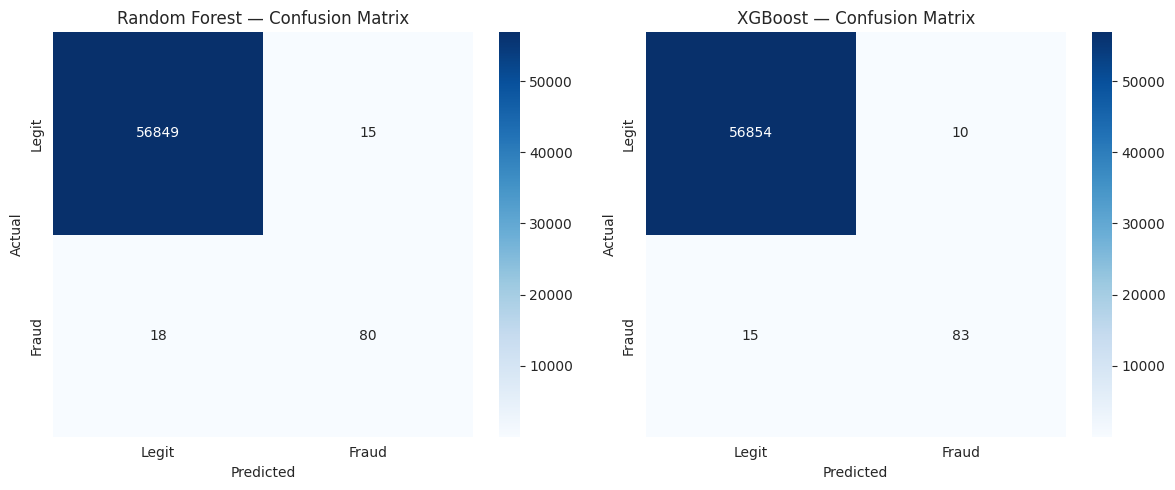

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred, xgb_pred]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

## 16. Saving Outputs

Saving the trained models and key plots for reproducibility and for inclusion as
supporting evidence in the report/repository.

In [ ]:
import os
import shutil
import joblib
import json
import matplotlib.pyplot as plt

os.makedirs("output", exist_ok=True)

# ---------------------------------------------------------
# 1. Save every currently-open matplotlib figure automatically
# ---------------------------------------------------------
saved_plots = []
for i, fig_num in enumerate(plt.get_fignums(), start=1):
    fig = plt.figure(fig_num)
    fname = f"plot_{i:02d}.png"
    fig.savefig(f"output/{fname}", dpi=150, bbox_inches="tight")
    saved_plots.append(fname)

print("Saved plots:", saved_plots)

# ---------------------------------------------------------
# 2. Compile all key stats/metrics into one JSON + text report
# ---------------------------------------------------------
report = {}

# Dataset stats
report["dataset_shape"] = {"rows": df.shape[0], "columns": df.shape[1]}
report["class_distribution"] = df["Class"].value_counts().to_dict()
report["fraud_rate_percent"] = round(df["Class"].mean() * 100, 4)

# Correlation summary (top correlated features with target, if variable exists)
try:
    report["top_pearson_correlations_with_class"] = pearson_with_class.sort_values(
        ascending=False
    ).head(10).to_dict()
except NameError:
    pass

# Train/test split sizes
try:
    report["train_size"] = X_train.shape[0]
    report["test_size"] = X_test.shape[0]
    report["train_fraud_rate"] = round(y_train.mean(), 6)
    report["test_fraud_rate"] = round(y_test.mean(), 6)
except NameError:
    pass

# Model evaluation metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix
)

def metrics_dict(y_true, y_pred, y_proba):
    return {
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "mcc": round(matthews_corrcoef(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }

try:
    report["random_forest_metrics"] = metrics_dict(y_test, rf_pred, rf_proba)
    report["xgboost_metrics"] = metrics_dict(y_test, xgb_pred, xgb_proba)
except NameError:
    pass

# Cross-validation scores
try:
    report["random_forest_cv_f1"] = {
        "scores": rf_cv_scores.tolist(),
        "mean": round(rf_cv_scores.mean(), 4),
        "std": round(rf_cv_scores.std(), 4),
    }
    report["xgboost_cv_f1"] = {
        "scores": xgb_cv_scores.tolist(),
        "mean": round(xgb_cv_scores.mean(), 4),
        "std": round(xgb_cv_scores.std(), 4),
    }
except NameError:
    pass

# Error analysis
try:
    report["error_analysis"] = {
        "random_forest_fn_count": len(rf_fn),
        "random_forest_fp_count": len(rf_fp),
        "xgboost_fn_count": len(xgb_fn),
        "xgboost_fp_count": len(xgb_fp),
        "xgboost_fn_amount_stats": xgb_fn["Amount"].describe().to_dict(),
    }
except NameError:
    pass

# Save as JSON (machine-readable, good for report tables)
with open("output/results_summary.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

# Save as readable text file too (easy to paste into report/README)
with open("output/results_summary.txt", "w") as f:
    for key, value in report.items():
        f.write(f"{key}:\n{value}\n\n")

print("Saved: results_summary.json and results_summary.txt")

# ---------------------------------------------------------
# 3. Save trained models + processed data
# ---------------------------------------------------------
try:
    joblib.dump(rf_model, "output/random_forest_model.pkl")
    joblib.dump(xgb_model, "output/xgboost_model.pkl")
    print("Saved: model files")
except NameError:
    print("Warning: models not found in memory, skipping model save")

try:
    model_df.to_csv("output/processed_data.csv", index=False)
    print("Saved: processed_data.csv")
except NameError:
    pass

# ---------------------------------------------------------
# 4. Zip everything
# ---------------------------------------------------------
shutil.make_archive("Credit_Card_Fraud_Project_Outputs", "zip", "output")
print("\nAll outputs zipped -> Credit_Card_Fraud_Project_Outputs.zip")
print("Contents:", os.listdir("output"))

Saved plots: []
Saved: results_summary.json and results_summary.txt
Saved: model files
Saved: processed_data.csv

All outputs zipped -> Credit_Card_Fraud_Project_Outputs.zip
Contents: ['random_forest_model.pkl', 'results_summary.json', 'processed_data.csv', 'xgboost_model.pkl', 'results_summary.txt']
